# Classification Assignment

Dear Students,

Aap sab ko **Classification Assignment** diya ja raha hai. Is assignment ka objective data preprocessing aur classification model develop karna hai.

### Assignment Requirements

* Dataset ko properly analyze karein.
* Missing values ko handle karein (agar available hon).
* Required encoding perform karein (agar zarurat ho).
* Feature Scaling apply karein (agar required ho).
* Agar dataset imbalanced ho to usay **Balanced Dataset** mein convert karein.
* Different Classification Models apply karein aur unki performance compare karein.
* Accuracy, Precision, Recall, F1-Score, Classification Report aur Confusion Matrix generate karein.
* Best performing model select karein.
* Hyperparameter Tuning karke model ki performance improve karein.
* Model ki accuracy ko maximum possible level tak optimize karne ki koshish karein.
* Har step ki proper explanation aur code comments bhi include karein.

### Submission

Assignment complete karke **GitHub Repository Link** ya **Google Drive Link** submit karein.

**Source Code, Jupyter Notebook (.ipynb), Dataset aur README file zaroor include karein.**

### Submission Deadline

**Last Date of Submission: 08-08-2026**

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Load Data

In [63]:
df = pd.read_csv(r'framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## Data Cleaning & EDA

In [64]:
df.shape

(4238, 16)

In [65]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [67]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [68]:
df.sample(2)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1595,0,62,3.0,0,0.0,0.0,0,1,0,249.0,176.0,89.0,24.49,75.0,81.0,0
13,0,41,3.0,0,0.0,1.0,0,1,0,332.0,124.0,88.0,31.31,65.0,84.0,0


In [69]:
numerical_columns = ['age', 'education', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
binary_columns = df.drop(columns = numerical_columns).columns

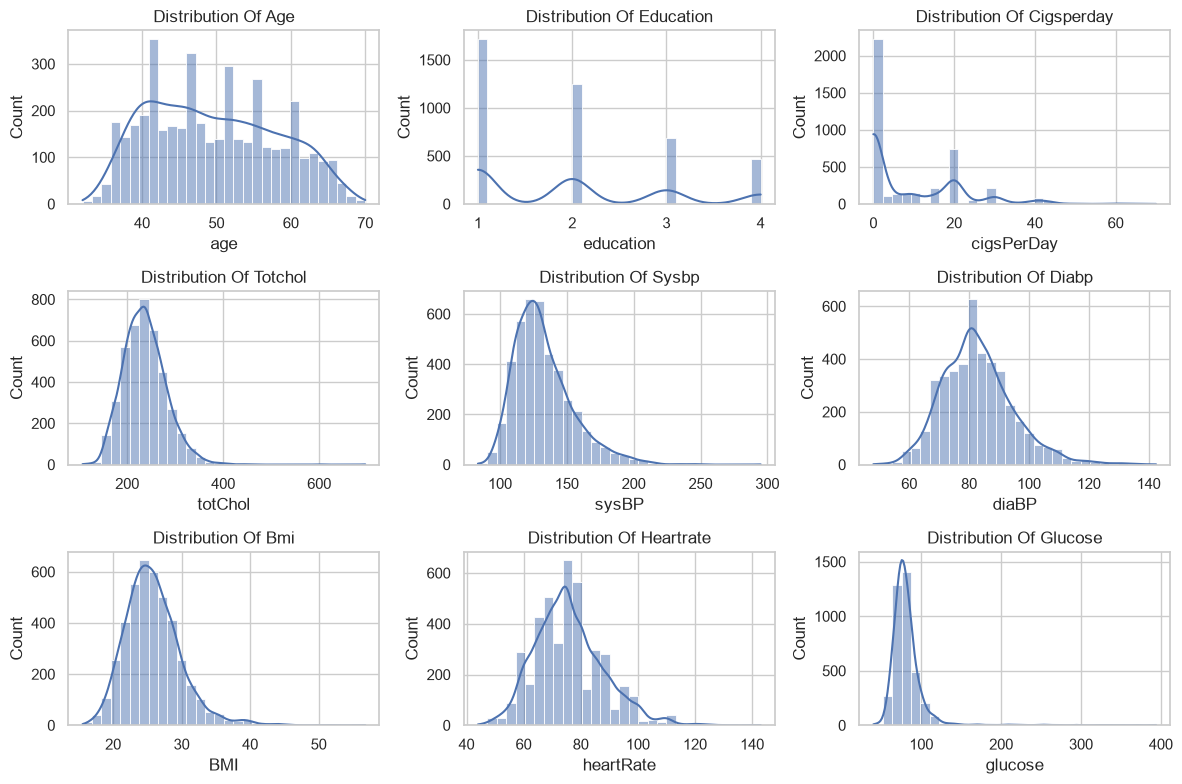

In [70]:
sns.set_theme(style="whitegrid", palette="deep")

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], ax = axes[i], kde = True, bins = 30)
    axes[i].set_title(f'distribution of {col}'.title())

plt.tight_layout()

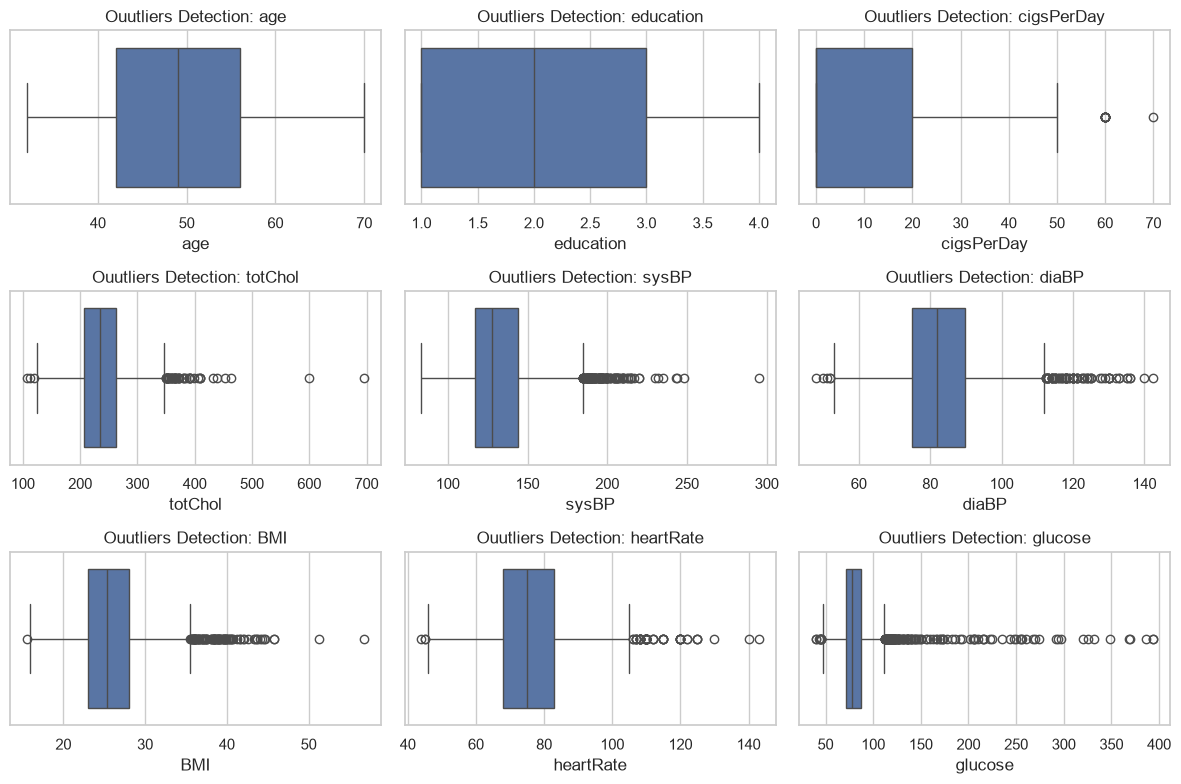

In [71]:
sns.set_theme(style="whitegrid", palette="deep")
fig, axes = plt.subplots(3, 3, figsize = (12, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(x = df[col], ax = axes[i])
    axes[i].set_title(f'Ouutliers Detection: {col}')

plt.tight_layout()
plt.show()

In [72]:
outliered_col = ['cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

In [73]:
for col in outliered_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower = lower_bound, upper = upper_bound)

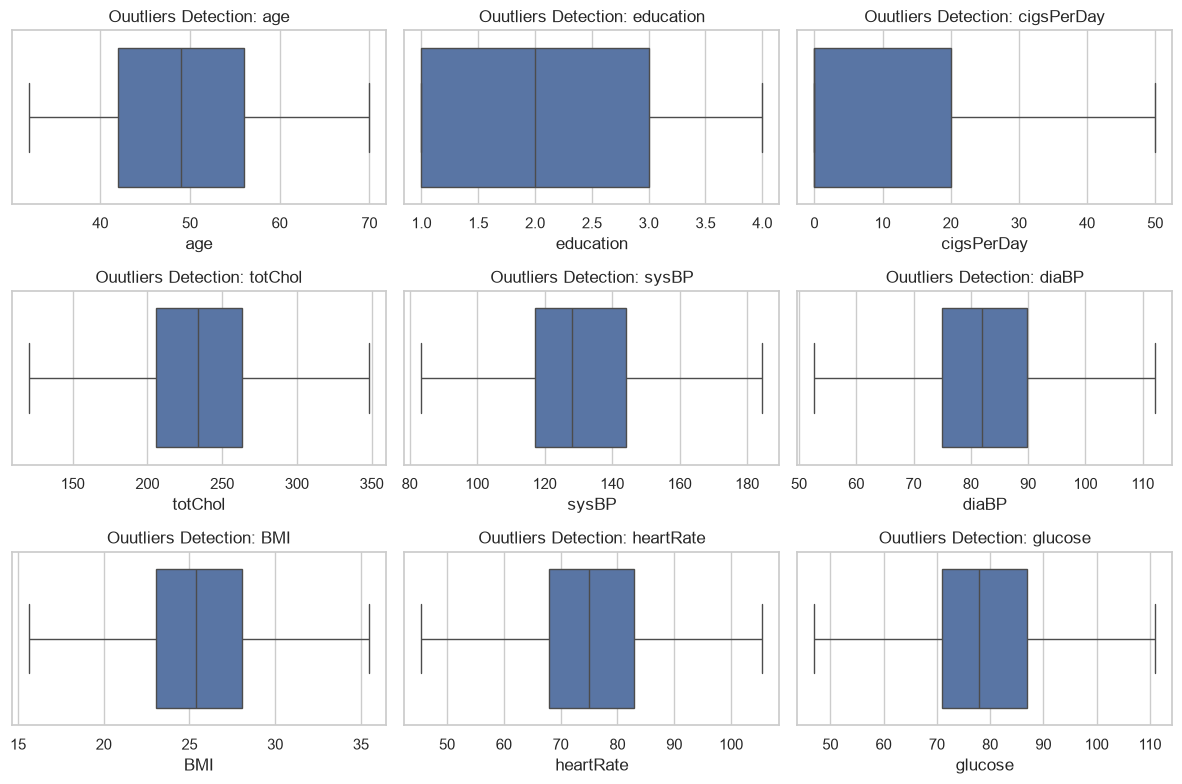

In [74]:
sns.set_theme(style="whitegrid", palette="deep")
fig, axes = plt.subplots(3, 3, figsize = (12, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(x = df[col], ax = axes[i])
    axes[i].set_title(f'Ouutliers Detection: {col}')

plt.tight_layout()
plt.show()

In [75]:
len(binary_columns)

7

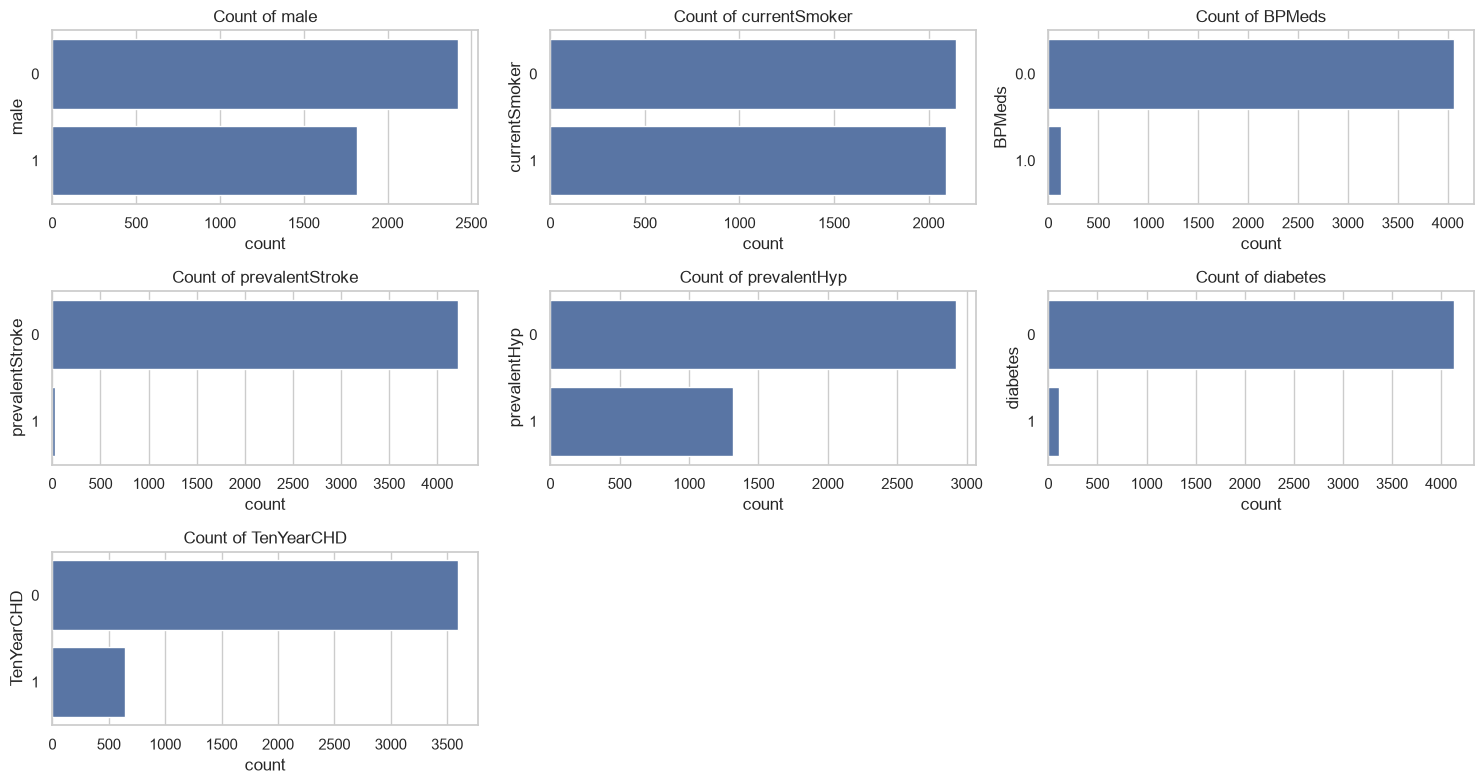

In [76]:
sns.set_theme(style = "whitegrid", palette = "deep")

fig, axes = plt.subplots(3, 3, figsize = (15, 8))
axes = axes.flatten()
sns.set_palette('viridis')

for i, col in enumerate(binary_columns):
    sns.countplot(y = df[col], ax = axes[i])
    axes[i].set_title(f'Count of {col}')

axes[7].remove()
axes[8].remove()
plt.tight_layout()
plt.show()

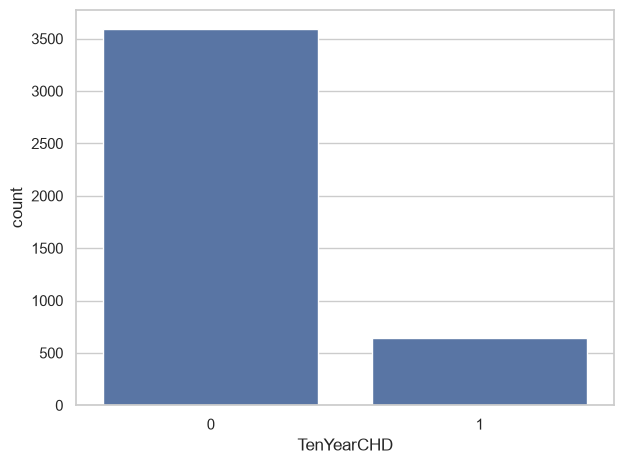

In [77]:
sns.set_theme(style = "whitegrid", palette = "deep")
sns.countplot(x = df['TenYearCHD'])
plt.tight_layout()
plt.show()

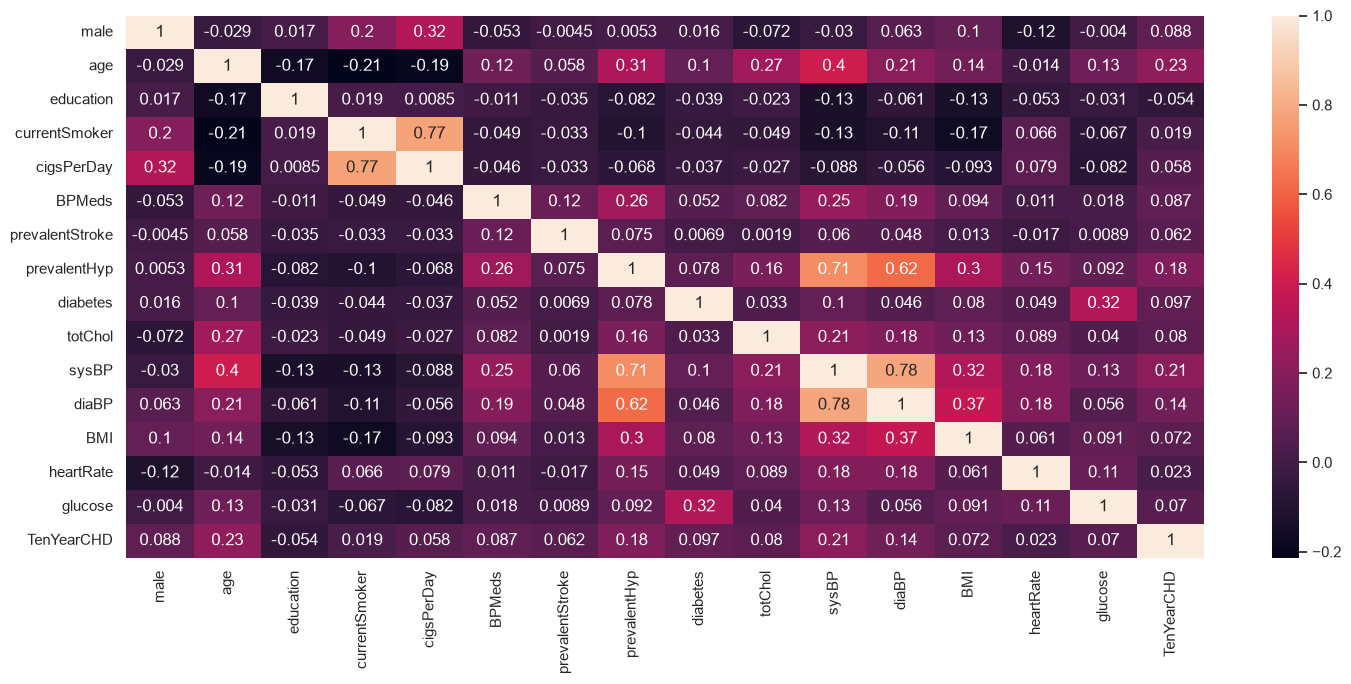

In [78]:
sns.set_theme(style = "whitegrid", palette = "deep")
plt.figure(figsize = (15, 7))
sns.heatmap(df.corr(), annot = True)
plt.tight_layout()
plt.show()

In [79]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [80]:
df.sample(5)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3846,1,57,1.0,0,0.0,1.0,0,1,0,321.0,184.5,112.1875,25.94,63.0,90.0,1
389,0,39,2.0,1,20.0,0.0,0,0,0,185.0,111.0,67.0000,23.87,70.0,87.0,0
252,0,39,1.0,0,0.0,0.0,0,0,0,182.0,109.0,70.0000,20.59,72.0,66.0,0
2961,1,52,1.0,0,0.0,0.0,0,1,1,258.0,177.0,111.0000,30.38,80.0,111.0,1
3420,0,42,4.0,0,0.0,0.0,0,0,0,238.0,125.0,77.5000,22.90,95.0,77.0,0


In [81]:
nan_columns = ['education', 'cigsPerDay', 'totChol', 'BMI', 'glucose', 'heartRate']
nan_columns_01 = 'BPMeds'

In [85]:
for col in nan_columns:
    df[col].fillna(df[col].mean(), inplace = True)

In [86]:
df[nan_columns_01].fillna(df[nan_columns_01].mode()[0], inplace = True)

In [87]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [88]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['TenYearCHD'])
y = df['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [90]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [91]:
y_train.value_counts()

TenYearCHD
0    2870
1    2870
Name: count, dtype: int64

## Models

In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report, confusion_matrix

In [110]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

## LogisticRegression

In [111]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

print('Train...')
print('Confusion metrics:\n', confusion_matrix(y_train, y_pred_train), '\n\n')
print('Classification report:\n', classification_report(y_train, y_pred_train))

print()

print('Test...')
print('Confusion metrics:\n', confusion_matrix(y_test, y_pred_test), '\n\n')
print('Classification report:\n', classification_report(y_test, y_pred_test))

Train...
Confusion metrics:
 [[1949  921]
 [ 907 1963]] 


Classification report:
               precision    recall  f1-score   support

           0       0.68      0.68      0.68      2870
           1       0.68      0.68      0.68      2870

    accuracy                           0.68      5740
   macro avg       0.68      0.68      0.68      5740
weighted avg       0.68      0.68      0.68      5740


Test...
Confusion metrics:
 [[471 253]
 [ 64  60]] 


Classification report:
               precision    recall  f1-score   support

           0       0.88      0.65      0.75       724
           1       0.19      0.48      0.27       124

    accuracy                           0.63       848
   macro avg       0.54      0.57      0.51       848
weighted avg       0.78      0.63      0.68       848



## DecisionTreeClassifier

In [118]:
dt_model = DecisionTreeClassifier(max_depth = 8)
dt_model.fit(X_train, y_train)

y_pred_train = dt_model.predict(X_train)
y_pred_test = dt_model.predict(X_test)

print('Train...')
print('Confusion metrics:\n', confusion_matrix(y_train, y_pred_train), '\n\n')
print('Classification report:\n', classification_report(y_train, y_pred_train))

print()

print('Test...')
print('Confusion metrics:\n', confusion_matrix(y_test, y_pred_test), '\n\n')
print('Classification report:\n', classification_report(y_test, y_pred_test))

Train...
Confusion metrics:
 [[2678  192]
 [ 807 2063]] 


Classification report:
               precision    recall  f1-score   support

           0       0.77      0.93      0.84      2870
           1       0.91      0.72      0.81      2870

    accuracy                           0.83      5740
   macro avg       0.84      0.83      0.82      5740
weighted avg       0.84      0.83      0.82      5740


Test...
Confusion metrics:
 [[630  94]
 [103  21]] 


Classification report:
               precision    recall  f1-score   support

           0       0.86      0.87      0.86       724
           1       0.18      0.17      0.18       124

    accuracy                           0.77       848
   macro avg       0.52      0.52      0.52       848
weighted avg       0.76      0.77      0.76       848

